In [ ]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
PROJECT_DIR = Path.cwd().parent      
SCRIPTS_DIR = PROJECT_DIR / "scripts"
DATA_RAW_DIR = PROJECT_DIR / "data_raw"
DATA_PROCESSED_DIR = PROJECT_DIR / "data_processed"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from reddit_preprocess import RedditPreprocessConfig, build_reddit_clean_df

In [3]:
RAW_PATH = DATA_RAW_DIR / "lol.csv" 

cfg = RedditPreprocessConfig(
    path=RAW_PATH,
    text_col="body",           # cambia si tu columna se llama distinto
    created_col="created_utc", # o "created" si es el caso
    id_col="id",
    min_text_len=3,
)

df_clean = build_reddit_clean_df(cfg)

print(df_clean.head())
print(df_clean.dtypes)
print(f"Número de comentarios después de limpiar: {len(df_clean):,}")

                                                body          created_utc  \
0  Done - your wish is our command.  Graves shall...  2017-04-01 16:01:43   
1  I don't play league but goddam it if I'm not g...  2017-04-01 03:56:12   
2         http://imgur.com/a/8F7c6 WE DID IT REDDIT!  2017-04-01 04:01:06   
3                                        Seems legit  2017-04-01 00:55:50   
4  Graves no cigar, graves in peril, not to worry...  2017-04-01 01:19:17   

   score          created_dt        date  year  month year_month  \
0   2022 2017-04-01 16:01:43  2017-04-01  2017      4    2017-04   
1   4183 2017-04-01 03:56:12  2017-04-01  2017      4    2017-04   
2    267 2017-04-01 04:01:06  2017-04-01  2017      4    2017-04   
3    978 2017-04-01 00:55:50  2017-04-01  2017      4    2017-04   
4    670 2017-04-01 01:19:17  2017-04-01  2017      4    2017-04   

                                          text_clean  \
0  done your wish is our command graves shall onc...   
1  i don t play 

In [4]:
print(df_clean["year"].value_counts().sort_index())

print(df_clean[["n_tokens", "n_tokens_no_stop", "n_chars"]].describe())

year
2015      279
2016      187
2017     1085
2018     1780
2019     2523
2020    10004
2021     4498
2022     1175
2024       98
2025     4630
Name: count, dtype: int64
           n_tokens  n_tokens_no_stop       n_chars
count  26259.000000      26259.000000  26259.000000
mean      21.700522         10.351346    113.427929
std       44.067654         31.064280    226.478239
min        0.000000          0.000000      3.000000
25%        6.000000          3.000000     32.000000
50%       11.000000          6.000000     59.000000
75%       23.000000         11.000000    116.000000
max     3333.000000       3333.000000  10000.000000


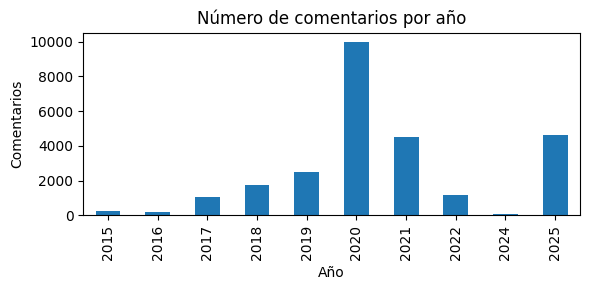

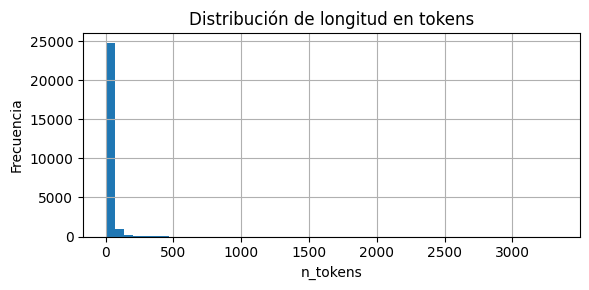

In [5]:
plt.figure(figsize=(6, 3))
df_clean["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Número de comentarios por año")
plt.xlabel("Año")
plt.ylabel("Comentarios")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
df_clean["n_tokens"].hist(bins=50)
plt.title("Distribución de longitud en tokens")
plt.xlabel("n_tokens")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


In [6]:
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
output_path = DATA_PROCESSED_DIR / "reddit_clean.csv"

df_clean.to_csv(output_path, index=False)
print(f"Guardado df_clean en: {output_path}")

Guardado df_clean en: c:\Users\lafp0\Documents\Github\ciencia-de-datos\7° semestre\procesamiento-lenguaje-natural\proyecto\data_processed\reddit_clean.csv
